# Notebook 04 — Sweep over fixed $\nu_b$ with period-specific post-switch $\xi_W$

This notebook implements the four-part structure in `Reference_notes/On_Calibration_variablet_set.md` for

$$
\nu_b\in\{0.1,0.5,1.0,1.3\}.
$$

All unswept primitives remain at the AHP-matching calibration used by Notebooks 01–03. In every calibration, $\nu_b$ is fixed within and across dates, while the absorbing-regime solver chooses a state-specific $\xi_{W,t}^{eff}$ satisfying

$$
\nu_b\log G_{N,US,t}^{b}=\xi_{W,t}^{eff}\log G_{N,W,t}^{b}.
$$

The all-$u$ branch retains the primitive seed $\xi_W=1$. The source common-growth directory is neither read nor modified.

The notebook first tests $T=80$ with `n_buffer=0`. When that test is unavailable, it finds the largest connected residual-safe horizon and plots only through $\min\{80,T_{\max}\}$. Numerical continuation failures are reported rather than silently omitted.

In [1]:
const NB04_HELPER_CANDIDATES = unique(normpath.([
    joinpath(pwd(), "Two_country_production_com_g_recal_xi_W", "04_nu_b_sweep_diagnostics_recal_xi_W.jl"),
    joinpath(pwd(), "Codes", "Two_country_production_com_g_recal_xi_W", "04_nu_b_sweep_diagnostics_recal_xi_W.jl"),
    joinpath(pwd(), "04_nu_b_sweep_diagnostics_recal_xi_W.jl"),
    joinpath(dirname(pwd()), "Two_country_production_com_g_recal_xi_W", "04_nu_b_sweep_diagnostics_recal_xi_W.jl"),
]))
helper_idx = findfirst(isfile, NB04_HELPER_CANDIDATES)
isnothing(helper_idx) && error("Cannot find Notebook 04 helper; checked:\n" * join(NB04_HELPER_CANDIDATES, "\n"))
include(NB04_HELPER_CANDIDATES[helper_idx])

@assert NB04_NU_B_GRID == [0.1, 0.5, 1.0, 1.3]
@assert NB04_SWITCH_DATE == 5
@assert NB04_TARGET_HORIZON == 80
nothing

  Activating 

Notebook 04 helper loaded


project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/julia_env`


Model:       /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/TwoCountryProductionOLG.jl
Output dir:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics
nu_b grid:   

[0.1, 0.5, 1.0, 1.3]
switch date: 5


## Residual-safe, no-buffer horizons

For each calibration, the reported plotting horizon is

$$
\min\{80,T_{\max}\}.
$$

`T_max` below is a numerical continuation frontier, not an existence or non-existence theorem. The search records the $T=80$ attempt, the successful continuation sequence, and the first failed integer horizon in machine-readable form.

In [2]:
nu_b_sweep = nb04_solve_grid()
display(nb04_horizon_table(nu_b_sweep.summary))
println("Horizon-search attempts: ", joinpath(NB04_OUTDIR, "horizon_search_attempts.csv"))
println("Horizon summary:         ", joinpath(NB04_OUTDIR, "horizon_summary.csv"))
nothing

nu_b=0.10 stage=direct_T80 T=80 iters=60: residual-safe, max u/bgp 4.305e-06 / 2.244e-11
nu_b=0.10 stage=T80_refinement T=80 iters=200: residual-safe, max u/bgp 2.682e-07 / 2.244e-11


nu_b=0.50 stage=direct_T80 T=80 iters=60: unavailable (Absorbing-BGP continuation failed during initialization at t=49.)
nu_b=0.50 stage=coarse_search T=5 iters=60: residual-safe, max u/bgp 1.183e-07 / 6.088e-10


nu_b=0.50 stage=coarse_search T=8 iters=60: residual-safe, max u/bgp 1.106e-07 / 6.101e-10
nu_b=0.50 stage=coarse_search T=10 iters=60: residual-safe, max u/bgp 1.192e-07 / 6.102e-10
nu_b=0.50 stage=coarse_search T=12 iters=60: residual-safe, max u/bgp 1.097e-07 / 6.103e-10
nu_b=0.50 stage=coarse_search T=15 iters=60: residual-safe, max u/bgp 1.367e-07 / 6.103e-10


nu_b=0.50 stage=coarse_search T=20 iters=60: residual-safe, max u/bgp 1.321e-07 / 8.946e-10
nu_b=0.50 stage=coarse_search T=25 iters=60: residual-safe, max u/bgp 1.387e-07 / 9.224e-10
nu_b=0.50 stage=coarse_search T=30 iters=60: residual-safe, max u/bgp 1.561e-07 / 9.248e-10
nu_b=0.50 stage=coarse_search T=45 iters=60: unavailable (Absorbing-BGP continuation failed during outer iteration 3 at the required terminal successor t=46.)


nu_b=0.50 stage=coarse_search T=45 iters=200: unavailable (Absorbing-BGP continuation failed during outer iteration 3 at the required terminal successor t=46.)
nu_b=0.50 stage=integer_refinement T=31 iters=60: residual-safe, max u/bgp 5.584e-08 / 9.327e-10


...

nu_b=1.30 stage=coarse_search T=5 iters=60: residual-safe, max u/bgp 1.016e-07 / 3.796e-11
nu_b=1.30 stage=coarse_search T=8 iters=60: residual-safe, max u/bgp 1.002e-07 / 4.463e-11
nu_b=1.30 stage=coarse_search T=10 iters=60: unavailable (Absorbing-BGP continuation failed during outer iteration 15 at the required terminal successor t=11.)
nu_b=1.30 stage=coarse_search T=10 iters=200: unavailable (Absorbing-BGP continuation failed during outer iteration 15 at the required terminal successor t=11.)


nu_b=1.30 stage=integer_refinement T=9 iters=60: residual-safe, max u/bgp 7.574e-08 / 4.796e-11


| nu_b | available |   direct T=80 | T_max | min(80,T_max) | next failed T | max u resid. | max BGP resid. |   xi*W*eff range | max CG log gap |
| ----:| ---------:| -------------:| -----:| -------------:| -------------:| ------------:| --------------:| ----------------:| --------------:|
|  0.1 |      true | residual_safe |    80 |            80 |       missing |     2.68e-07 |       2.24e-11 | [0.0477, 0.0625] |       9.62e-09 |
|  0.5 |      true |   unavailable |    44 |            44 |            45 |     1.63e-08 |       9.31e-10 | [0.3011, 2.8381] |       9.22e-09 |
|  1.0 |      true |   unavailable |    13 |            13 |            14 |     6.76e-08 |       7.46e-10 | [0.6022, 2.5568] |       7.84e-09 |
|  1.3 |      true |   unavailable |     9 |             9 |            10 |     7.57e-08 |       4.80e-11 | [0.7828, 2.5323] |       4.62e-09 |


Horizon-search attempts: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/horizon_search_attempts.csv


Horizon summary:         /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/horizon_summary.csv


## Recalibrated $\xi_W$ paths across the $\nu_b$ grid

Before turning to the four diagnostic sections, compare the period-specific absorbing-regime calibration itself. At every possible switch date $t$, the absorbing equilibrium is evaluated at the predetermined state inherited from the all-$u$ history and chooses

$$
\xi_{W,t}^{eff}
=\nu_b\frac{\log G_{N,US,t}^{b}}{\log G_{N,W,t}^{b}}
$$

so that post-switch U.S. and RoW productivity grow at the common rate. Each line stops at that calibration's reported $\min\{80,T_{\max}\}$ horizon. The dotted line is the primitive all-$u$ seed $\xi_W=1$; it is a reference and is not fed into the absorbing solve. These are state-matched possible-switch paths, not a single realized sequence of switches.

nu_b=0.1: xi_W_eff range [0.048339, 0.062464] over T=80
nu_b=0.5: xi_W_eff range [0.301086, 2.810335] over T=44


nu_b=1.0: xi_W_eff range [0.602173, 1.662306] over T=13
nu_b=1.3: xi_W_eff range [0.782825, 1.792365] over T=9


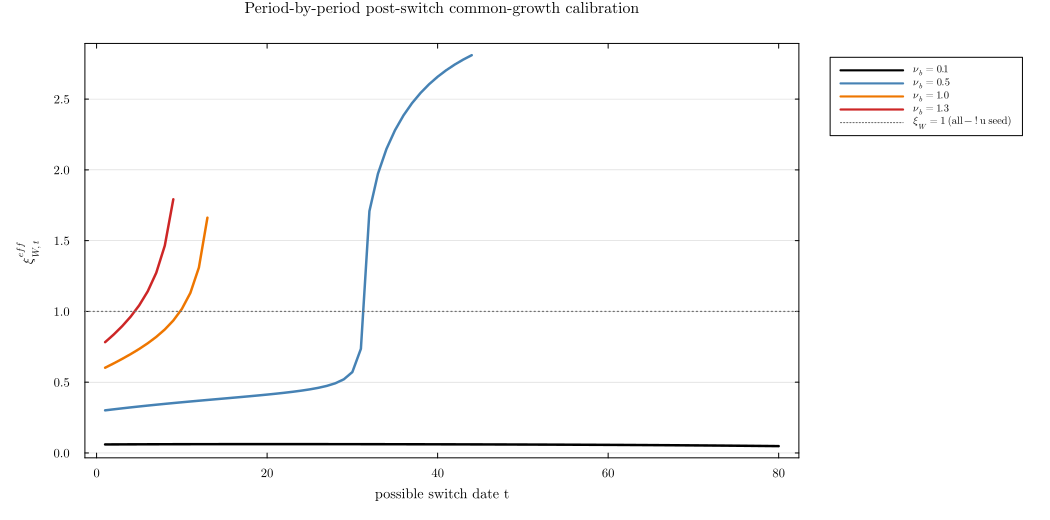

In [3]:
xi_W_sweep_paths = nb04_plot_xi_W_paths(nu_b_sweep)
for case in NB04_CASES
    case_rows = filter(r -> r.nu_b == case.nu_b, xi_W_sweep_paths.rows)
    isempty(case_rows) && continue
    values = [r.xi_W_eff for r in case_rows]
    @printf("nu_b=%.1f: xi_W_eff range [%.6f, %.6f] over T=%d\n",
            case.nu_b, minimum(values), maximum(values), length(values))
end
xi_W_sweep_paths.figure

## 1. R&D allocation, growth, and the U.S. stock-funding identity

### 1.1 All-$u$ and realized switch-to-$b$ paths

For each calibration, country, and path, the figure reports

$$
\varphi_{i,t},\quad e_{i,t},\quad Q_{i,t},\quad q_{i,t},\quad N_{i,t},
\qquad i\in\{US,W\}.
$$

The solid line is the all-$u$ path. The dashed line is a realized path that follows $u$ for $t<\tau$ and the absorbing regime for $t\ge\tau$. A common switch date $\tau=5$ is used because the residual-safe horizons for the two largest $\nu_b$ values are shorter than the original 15-period AHP evidence window. The vertical dotted line marks $\tau$. Recall that $\varphi$ is the production share of skilled labour; the R&D share is $1-\varphi$.

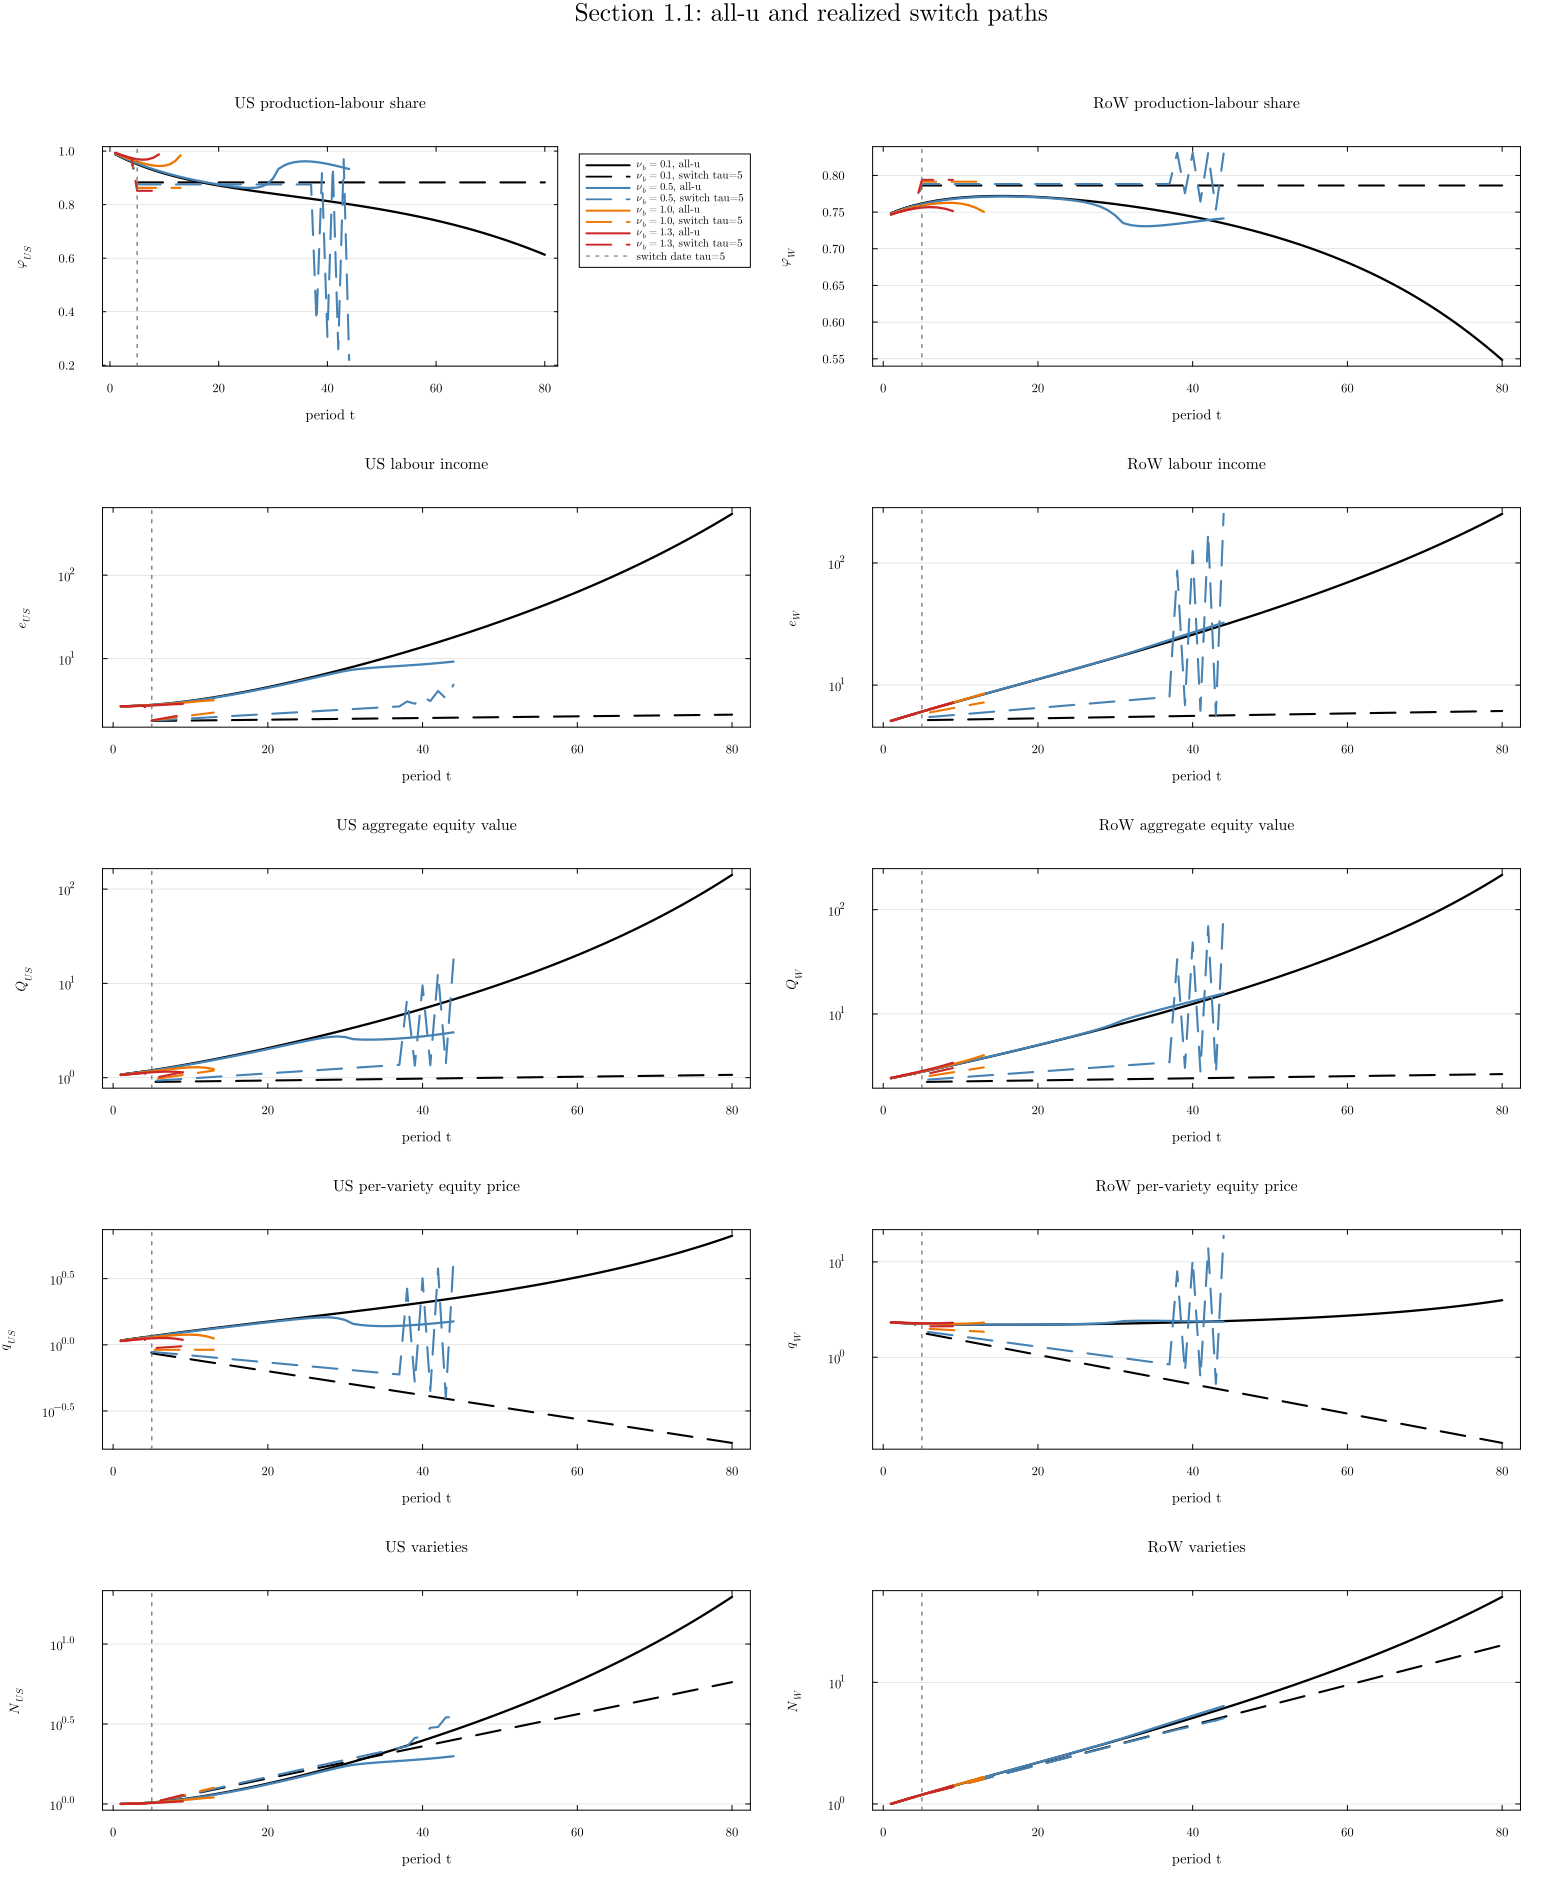

In [4]:
nu_b_diagnostics = nb04_build_diagnostics(nu_b_sweep)
growth_paths_figure = nb04_plot_growth_paths(nu_b_diagnostics)
growth_paths_figure

### 1.2 U.S. stock-funding components

Along the all-$u$ path,

$$
A_t=\frac{s_W e^u_{W,t}}{\beta e^u_{US,t}},\qquad
B_t=\frac{Q^u_{W,t}}{\beta e^u_{US,t}},\qquad
\zeta_t=1+A_t-B_t,
$$

where $s_W=(\beta+\chi)/(1+\chi)$. The equivalent representation is

$$
m_t=\frac{e^u_{W,t}}{e^u_{US,t}},\qquad
\mu_t=\frac{Q^u_{W,t}}{e^u_{W,t}},\qquad
\zeta_t=1+\frac{m_t}{\beta}(s_W-\mu_t).
$$

In the last panel, the solid direct $\zeta_t$ and dashed reconstructed series are superimposed.

nu_b=0.1: max funding-identity error 2.380e-08
nu_b=0.5: max funding-identity error 1.340e-09


nu_b=1.0: max funding-identity error 9.252e-09
nu_b=1.3: max funding-identity error 1.058e-08


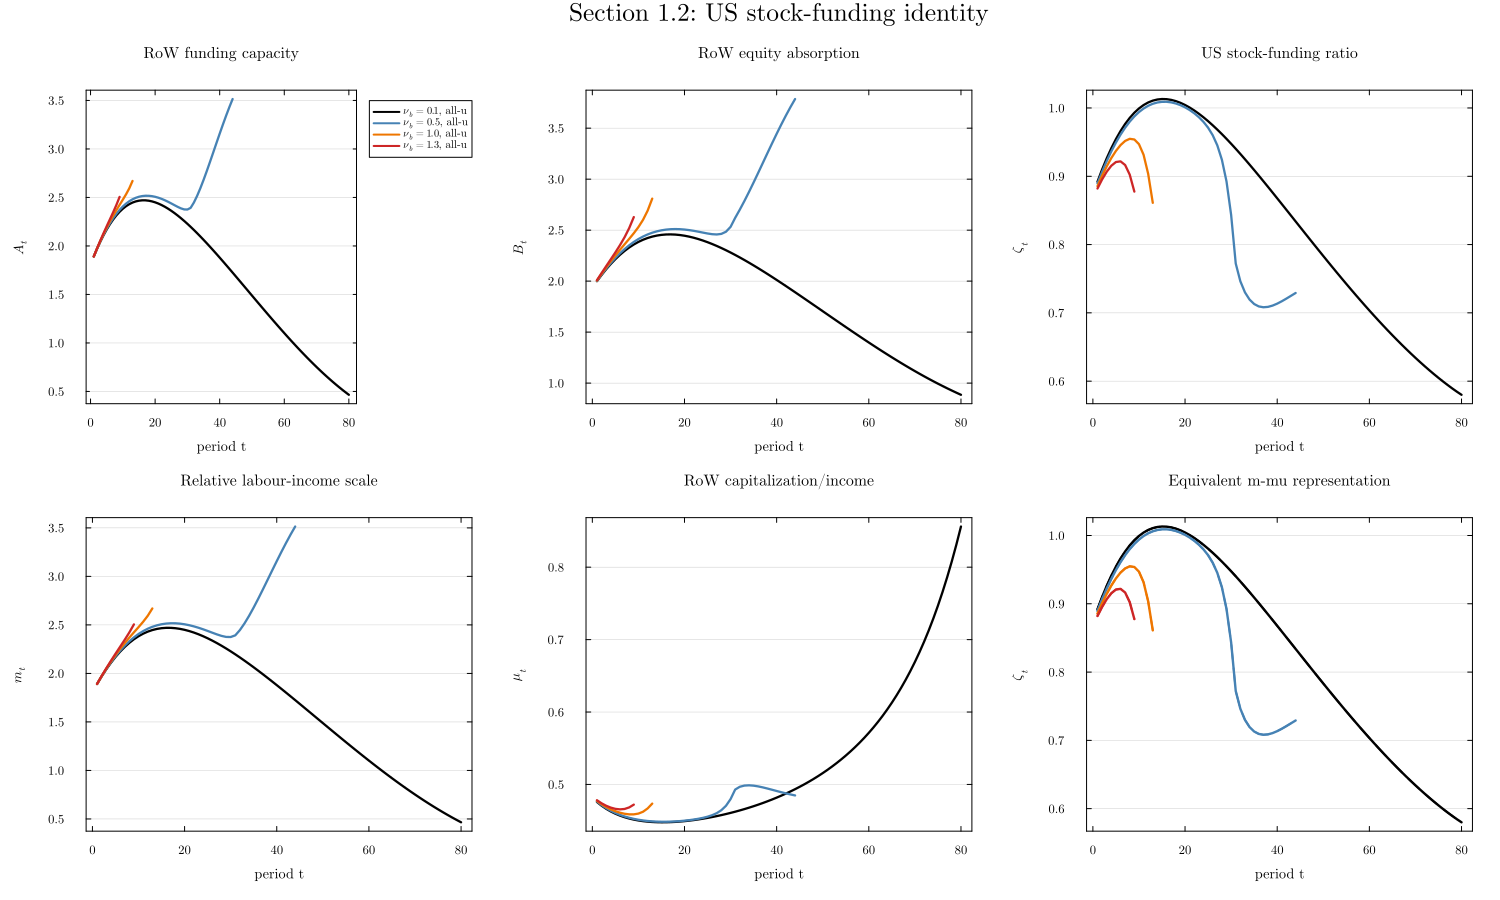

In [5]:
funding_figure = nb04_plot_funding(nu_b_diagnostics)
for d in nu_b_diagnostics
    @printf("nu_b=%.1f: max funding-identity error %.3e\n",
            d.case.nu_b, d.funding.identity_error)
end
funding_figure

## 2. Finite-prefix diagnostics for the HKT tail reduction

The panels report

$$
\frac{e_W}{e_{US}},\quad
\frac{Q_W}{\beta e_{US}},\quad
\frac{Q_W}{\beta e_W},\quad
\frac{Q_{US}}{\beta e_W},\quad
\zeta=\frac{Q_{US}}{\beta e_{US}},
$$

together with

$$
\Lambda_t^u,\qquad \Lambda_t^b,\qquad
\frac{\Lambda_t^u}{\Lambda_t^b},\qquad
\Lambda_t^z=\frac{R_{A,t}^z}{R_{US,t}^z}.
$$

These are finite solved-prefix diagnostics. They do not establish that the required dominance inequalities hold on the infinite tail.

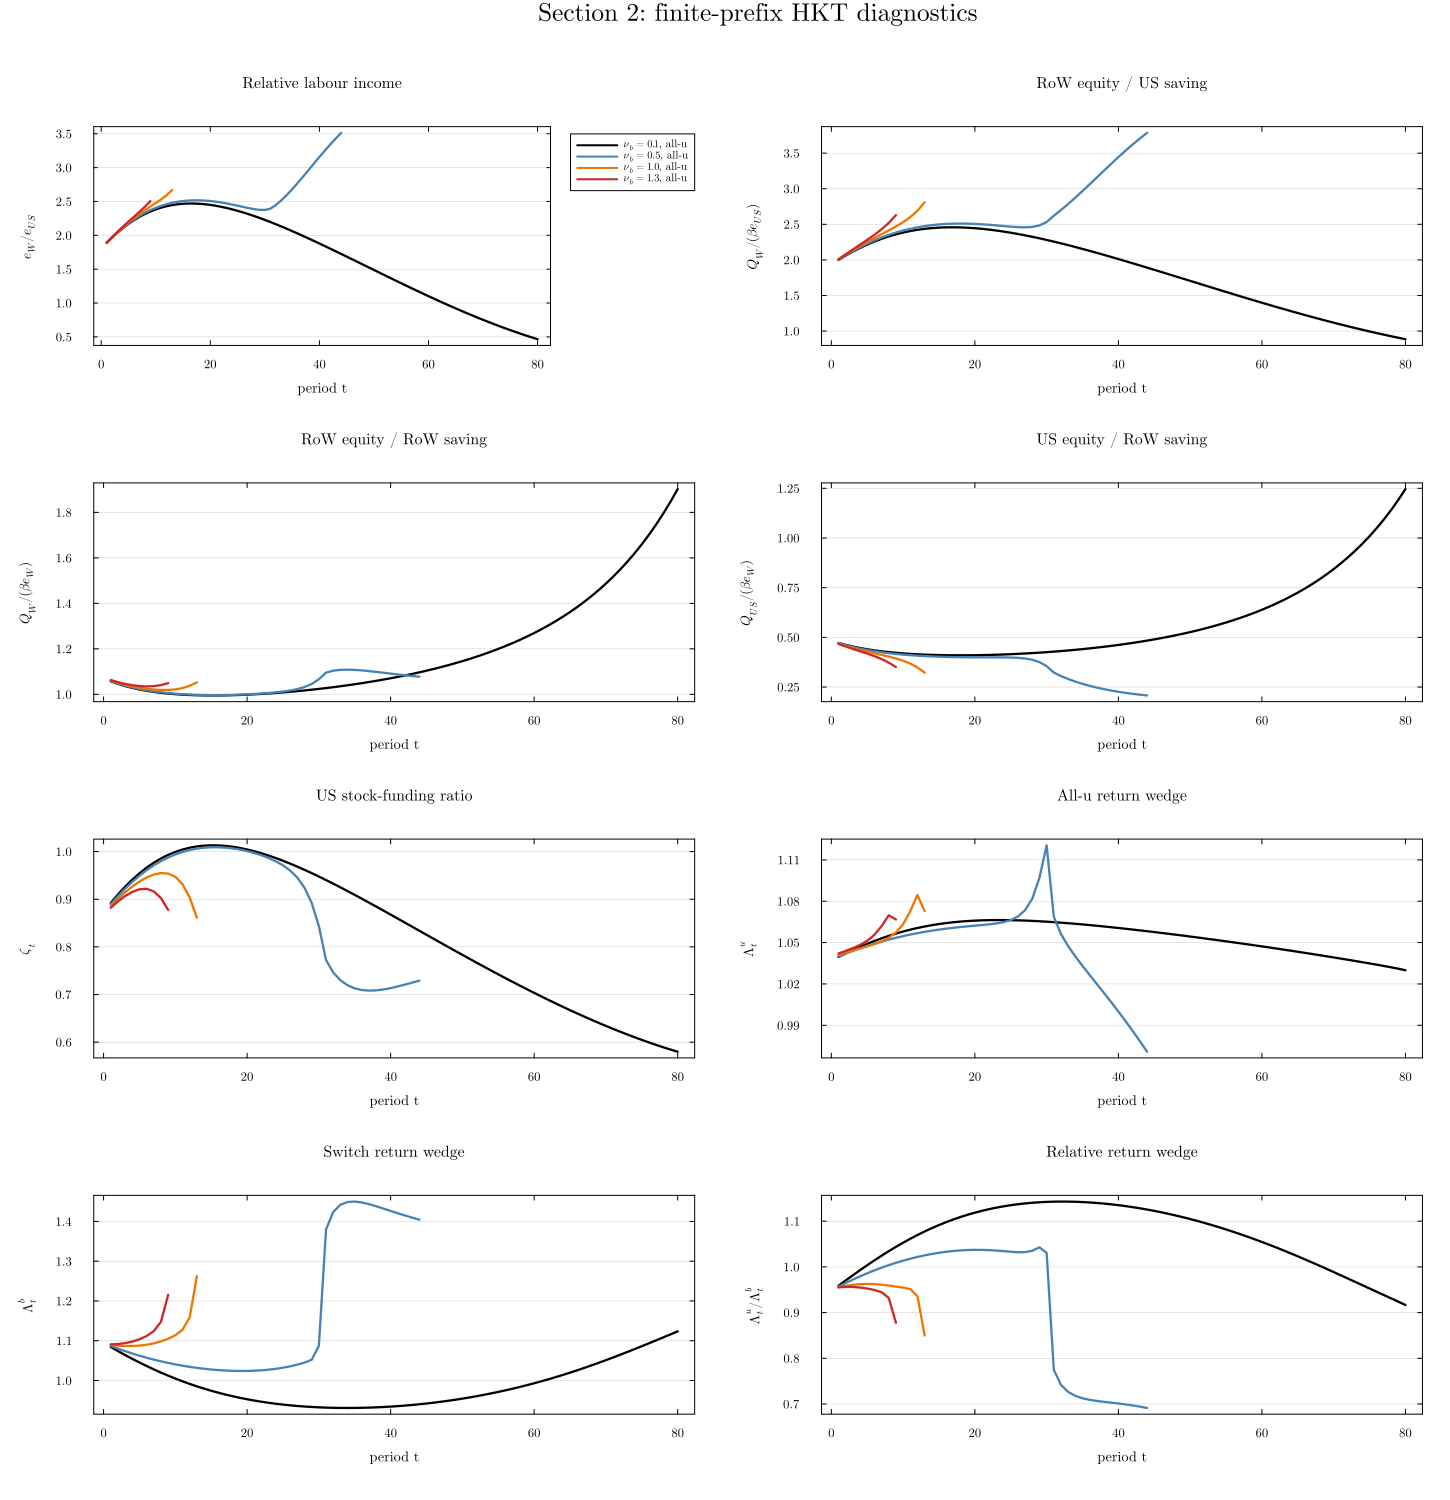

In [6]:
hkt_prefix_figure = nb04_plot_hkt(nu_b_diagnostics)
hkt_prefix_figure

## 3. U.S. NFA moments and VA/CA decomposition

The exact position accounting is

$$
\Delta NFA_t=VA_t+CA_t,
$$

with

$$
VA_t=n_{W,t-1}(q_{W,t}-q_{W,t-1})
-n^*_{US,t-1}(q_{US,t}-q_{US,t-1}),
$$

and

$$
CA_t=q_{W,t}(n_{W,t}-n_{W,t-1})
-q_{US,t}(n^*_{US,t}-n^*_{US,t-1})
+(b_t-b_{t-1}).
$$

Flow panels divide every term at date $t$ by current U.S. output solely for readability, so the adding-up identity is unchanged. The CSV export retains both level terms and the scale variable. Liability terms carry their economic minus signs.

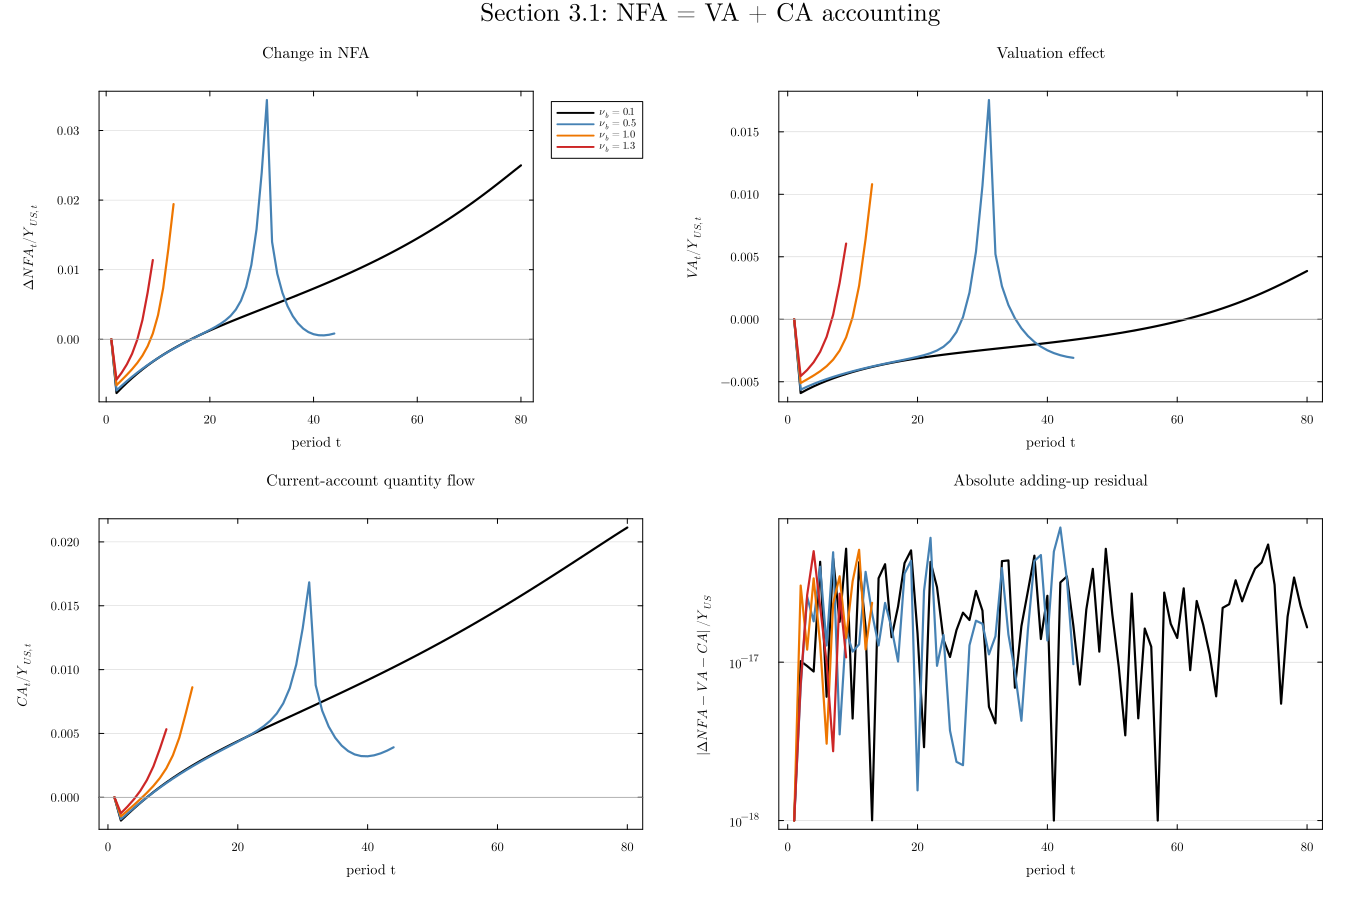

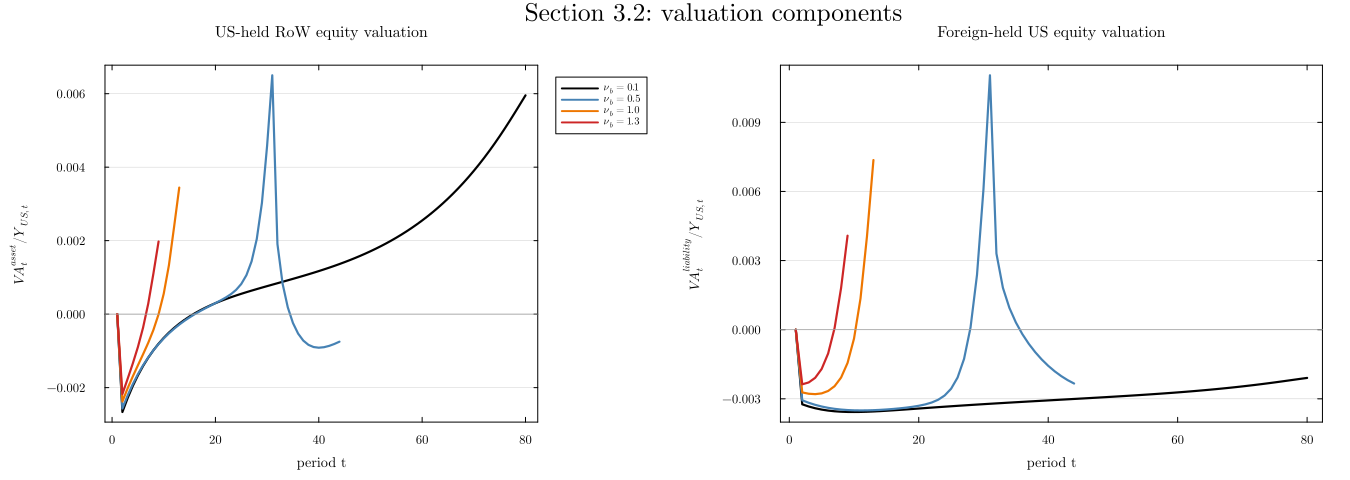

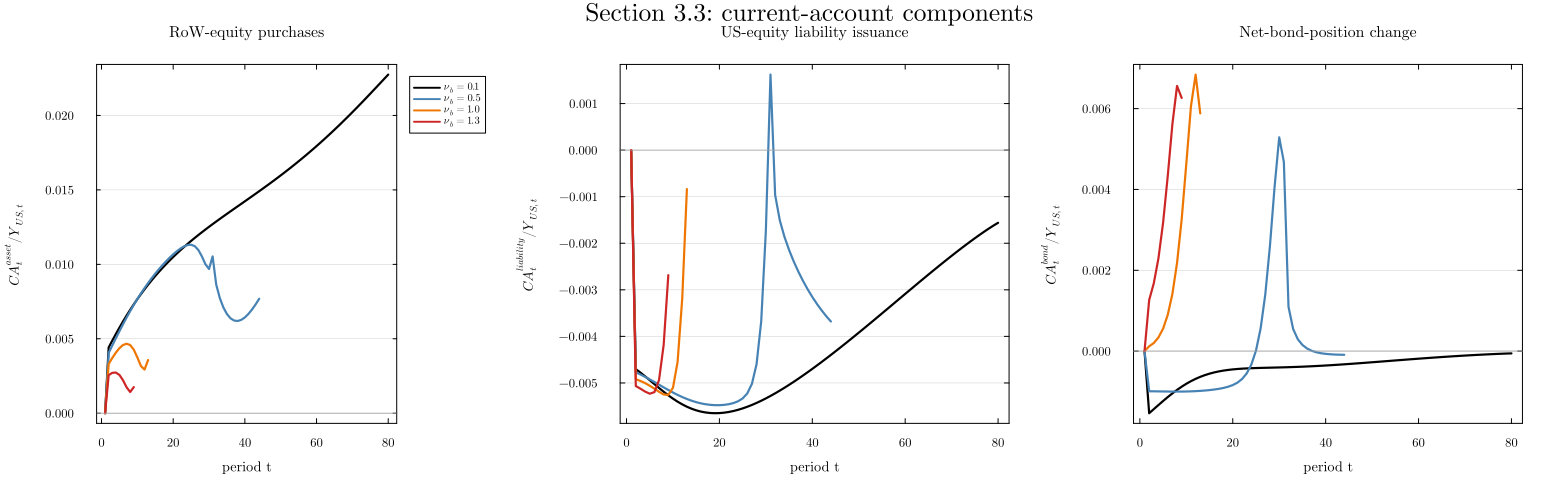

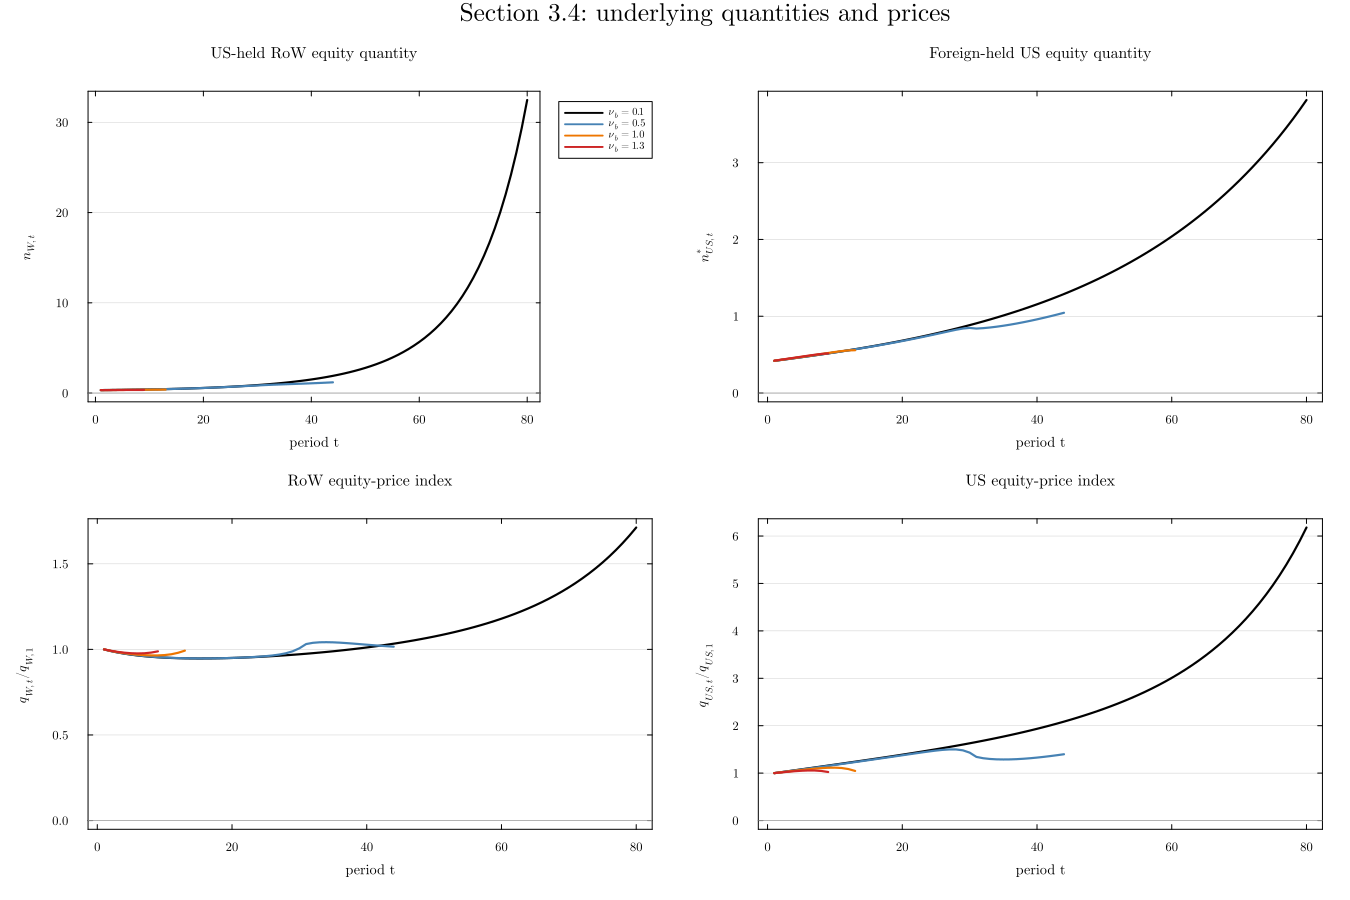

nu_b=0.1: max |Delta NFA - VA - CA| 1.421e-14; equilibrium NFA identity 2.063e-07
nu_b=0.5: max |Delta NFA - VA - CA| 6.314e-16; equilibrium NFA identity 2.602e-09


nu_b=1.0: max |Delta NFA - VA - CA| 1.596e-16; equilibrium NFA identity 9.833e-09
nu_b=1.3: max |Delta NFA - VA - CA| 1.388e-16; equilibrium NFA identity 1.064e-08


In [7]:
nfa_figures = nb04_plot_nfa(nu_b_diagnostics)
display(nfa_figures.flows)
display(nfa_figures.va)
display(nfa_figures.ca)
display(nfa_figures.positions)
for d in nu_b_diagnostics
    @printf("nu_b=%.1f: max |Delta NFA - VA - CA| %.3e; equilibrium NFA identity %.3e\n",
            d.case.nu_b, d.accounting.residual_max, d.accounting.nfa_identity_error)
end
nothing

## 4. U.S. bubble-share bound and leakage components

The finite solved-horizon product is

$$
\frac{B_{US,t}^u}{q_{US,t}^u}
\le \prod_{s=t+1}^{T_{\max}}\frac{1}{1+a_s},
$$

provided omitted-tail leakage is nonnegative. It is evaluated recursively in logs. Total leakage is decomposed as

$$
a_t=\frac{d_t^u}{q_t^u}
+\frac{1-\pi}{\pi}
\left(\frac{C_t^u}{C_t^b}\right)^\gamma
\frac{q_t^b+d_t^b}{q_t^u}.
$$

The switch term is further split into its relative state-price/SDF factor and physical payoff-crash factor. The displayed product is a finite-horizon diagnostic upper bound, not a certified infinite-horizon bubble share.

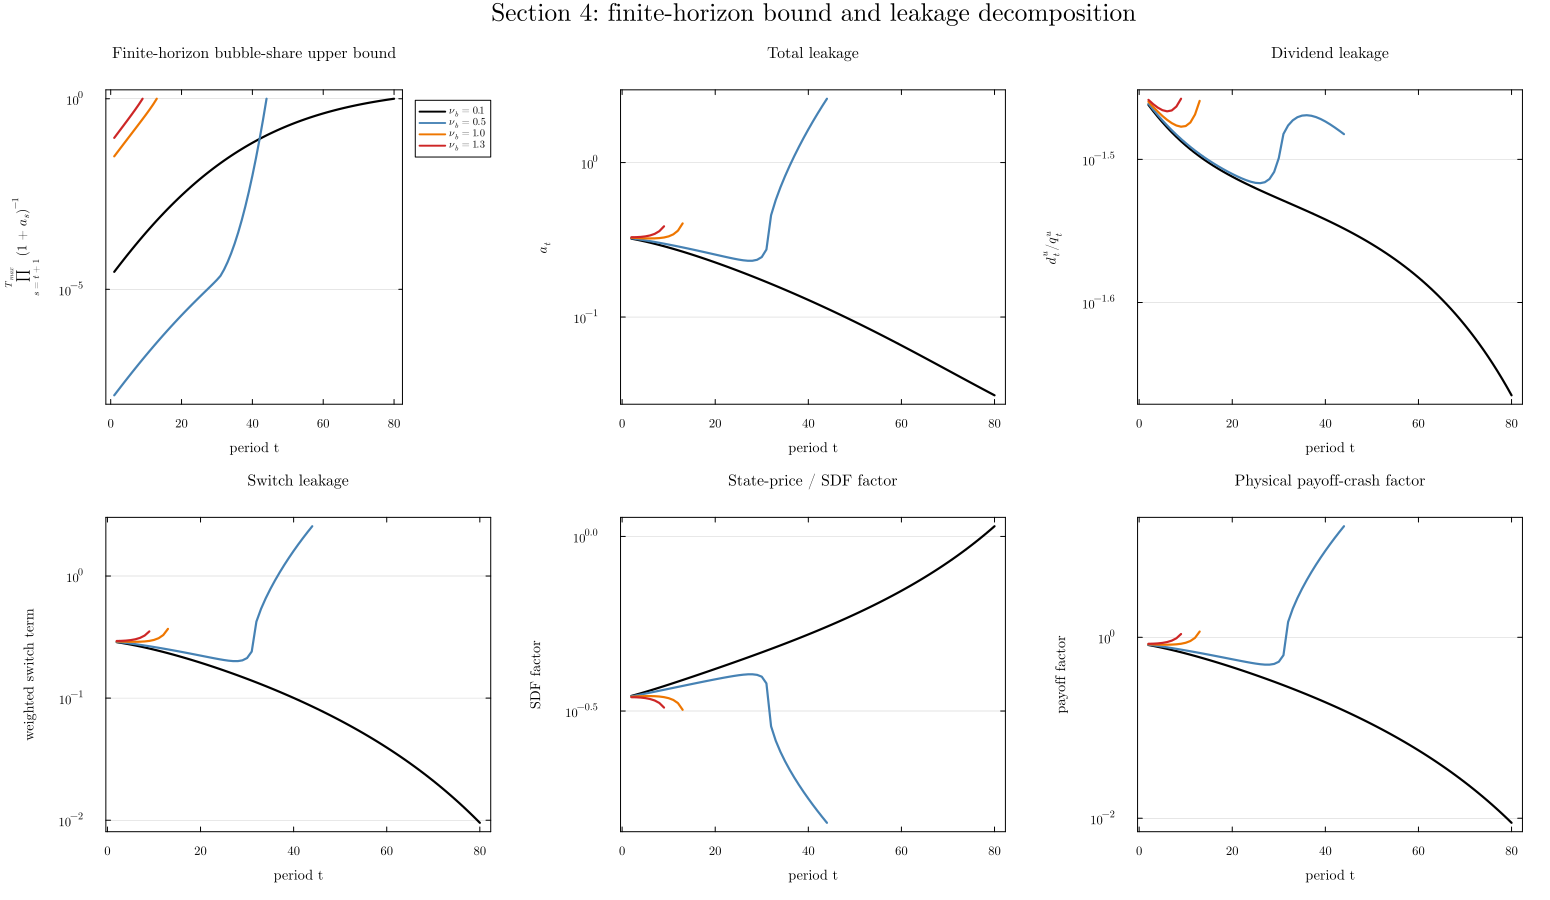

In [8]:
leakage_figure = nb04_plot_leakage(nu_b_diagnostics)
leakage_figure

## Verification and saved artifacts

The final checks require all four requested calibrations, the correct $\min\{80,T_{\max}\}$ plotting rule, residual-safe no-buffer solutions, fixed $\nu_b$, period-specific common-growth $\xi_W$, exact funding and leakage identities, and negligible NFA adding-up residuals.

Failures above a calibration's verified horizon remain in `horizon_search_attempts.csv`; they are not interpolated or reclassified as economic non-existence.

In [9]:
verification_rows = nb04_export_diagnostics(nu_b_diagnostics)
display(nb04_verification_table(verification_rows))
nb04_assert_definition_of_done(nu_b_sweep, nu_b_diagnostics, verification_rows)

println("Saved Notebook 04 artifacts:")
for path in sort(readdir(NB04_OUTDIR; join=true))
    println("  ", path)
end
nothing

| nu_b |   T | funding id. | NFA add-up | NFA equilibrium id. | leakage id. | switch factor id. | fixed nu_b err. | CG log gap | residual-safe |
| ----:| ---:| -----------:| ----------:| -------------------:| -----------:| -----------------:| ---------------:| ----------:| -------------:|
|  0.1 |  80 |    2.38e-08 |   1.42e-14 |            2.06e-07 |    2.78e-17 |          5.55e-17 |        0.00e+00 |   9.62e-09 |          true |
|  0.5 |  44 |    1.34e-09 |   6.31e-16 |            2.60e-09 |    2.78e-17 |          4.44e-16 |        0.00e+00 |   9.22e-09 |          true |
|  1.0 |  13 |    9.25e-09 |   1.60e-16 |            9.83e-09 |    0.00e+00 |          5.55e-17 |        0.00e+00 |   7.84e-09 |          true |
|  1.3 |   9 |    1.06e-08 |   1.39e-16 |            1.06e-08 |    0.00e+00 |          5.55e-17 |        0.00e+00 |   4.62e-09 |          true |


NB04_DEFINITION_OF_DONE_OK
Saved Notebook 04 artifacts:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/00_recalibrated_xi_W_sweep_paths.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/00_recalibrated_xi_W_sweep_paths.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/horizon_search_attempts.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production_com_g_recal_xi_W/outputs_recal_xi_W/04_nu_b_sweep_diagnostics/horizon_summary.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_count